In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!unzip -qq /content/gdrive/MyDrive/finushka/нейро\ петрунина/Data_2_2.zip

# 2 модели

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib

In [ ]:
data_dir = pathlib.Path("raw-img")
print(f"Классов: {len(list(data_dir.glob('*')))}")

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

Количество классов: 10
Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


In [ ]:
class_names = train_ds.class_names
class_count = dict.fromkeys(class_names, 0)
for images, labels in train_ds:
    labels_np = labels.numpy()
    for label in labels_np:
        class_count[class_names[label]] += 1
print(class_count)

{'cane': 3916, 'cavallo': 2101, 'elefante': 1173, 'farfalla': 1683, 'gallina': 2505, 'gatto': 1337, 'mucca': 1467, 'pecora': 1438, 'ragno': 3842, 'scoiattolo': 1482}


In [ ]:
# подсчёт весов для обучающей выборки
total_images = 26179
class_weights = {i: total_images / (len(class_names) * class_count[class_names[i]]) for i in range(len(class_names))}
class_weights

{0: 0.6685137895812053,
 1: 1.2460257020466445,
 2: 2.231798806479113,
 3: 1.555496137849079,
 4: 1.045069860279441,
 5: 1.9580403889304412,
 6: 1.7845262440354466,
 7: 1.8205146036161335,
 8: 0.6813899010931806,
 9: 1.766464237516869}

In [ ]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 5)
val_ds = val_ds.skip(val_batches // 5)

print(f"Количество батчей в train: {tf.data.experimental.cardinality(train_ds)}")
print(f"Количество батчей в validation: {tf.data.experimental.cardinality(val_ds)}")
print(f"Количество батчей в test: {tf.data.experimental.cardinality(test_ds)}")

Количество батчей в train: 655
Количество батчей в validation: 132
Количество батчей в test: 32


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [ ]:
model_0 = models.Sequential()
model_0.add(layers.Input(shape=IMG_SIZE + (3,)))
model_0.add(layers.Rescaling(1./255))

model_0.add(data_augmentation)

model_0.add(layers.Conv2D(filters=8, kernel_size=3, padding='same', activation="relu"))# ))#
model_0.add(layers.BatchNormalization())
model_0.add(layers.MaxPooling2D(pool_size=2))
#model_0.add(layers.Activation('relu'))

model_0.add(layers.Conv2D(filters=16, kernel_size=3, padding='same', activation="relu"))# ))#
model_0.add(layers.BatchNormalization())
model_0.add(layers.MaxPooling2D(pool_size=2))
#model_0.add(layers.Activation('relu'))

model_0.add(layers.Conv2D(filters=32, kernel_size=3, padding='same', activation="relu"))# ))#
model_0.add(layers.BatchNormalization())
model_0.add(layers.MaxPooling2D(pool_size=2))
#model_0.add(layers.Activation('relu'))

model_0.add(layers.Conv2D(filters=64, kernel_size=3, padding='same', activation="relu"))# ))#
model_0.add(layers.BatchNormalization())
model_0.add(layers.MaxPooling2D(pool_size=2))
#model_0.add(layers.Activation('relu'))

model_0.add(layers.Conv2D(filters=128, kernel_size=3, padding='same', activation="relu"))# ))#
model_0.add(layers.BatchNormalization())
model_0.add(layers.MaxPooling2D(pool_size=2))
#model_0.add(layers.Activation('relu'))

model_0.add(layers.Conv2D(filters=256, kernel_size=3, padding='same', activation="relu"))# ))#
model_0.add(layers.BatchNormalization())
model_0.add(layers.MaxPooling2D(pool_size=2))
#model_0.add(layers.Activation('relu'))

model_0.add(layers.Flatten())
#model_0.add(layers.Dense(units=96, activation='relu'))

model_0.add(layers.Dropout(0.5))
model_0.add(layers.Dense(len(class_names), activation='softmax'))


In [ ]:
model_0.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             

 Total params: 436,538 (1.67 MB)

 Trainable params: 435,530 (1.66 MB)

 Non-trainable params: 1,008 (3.94 KB)

In [ ]:
model_0.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

callbacks_0 = [
  keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss'
  ),
  keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
  ),
  keras.callbacks.ModelCheckpoint(filepath="kr1_0.keras", save_best_only=True, monitor="val_loss")
]

history_0 = model_0.fit(
  train_ds,
  epochs=50,
  validation_data=val_ds,
  class_weight=class_weights,
  callbacks=callbacks_0,
  verbose=1
)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.2174 - loss: 4.3344 - val_accuracy: 0.3678 - val_loss: 1.9892 - learning_rate: 0.0010
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.3294 - loss: 3.3085 - val_accuracy: 0.3802 - val_loss: 2.3279 - learning_rate: 0.0010
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 77ms/step - accuracy: 0.4002 - loss: 2.8818 - val_accuracy: 0.2705 - val_loss: 2.4910 - learning_rate: 0.0010
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 85s 81ms/step - accuracy: 0.4431 - loss: 2.6878 - val_accuracy: 0.4248 - val_loss: 2.0577 - learning_rate: 0.0010
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 77ms/step - accuracy: 0.4727 - loss: 2.4324 - val_accuracy: 0.4666 - val_loss: 1.7144 - learning_rate: 0.0010
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.5116 - loss: 2.2515 - val_accuracy: 0.4341 - val_loss: 1.9022 - learning_rate: 0.0010
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 49s 75ms/step - accuracy: 0.5286 - l

In [ ]:
def plothistory(history, metric='accuracy'):
    acc = history.history[metric]
    val_acc = history.history[f"val_{metric}"]
    if metric == 'f1_score':
        acc = [np.average(x) for x in acc]
        val_acc = [np.average(x) for x in val_acc]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    ax[0].plot(epochs, acc, label="Точность на этапе обучения", color='brown')
    ax[0].plot(epochs, val_acc, "b", label="Точность на этапе проверки")
    ax[0].set_title("Точность на этапах обучения и проверки")
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(epochs, loss, label="Потери на этапе обучения", color='brown')
    ax[1].plot(epochs, val_loss, "b", label="Потери на этапе проверки")
    ax[1].set_title("Потери на этапах обучения и проверки")
    ax[1].legend()
    ax[1].grid(True)
    fig.show()

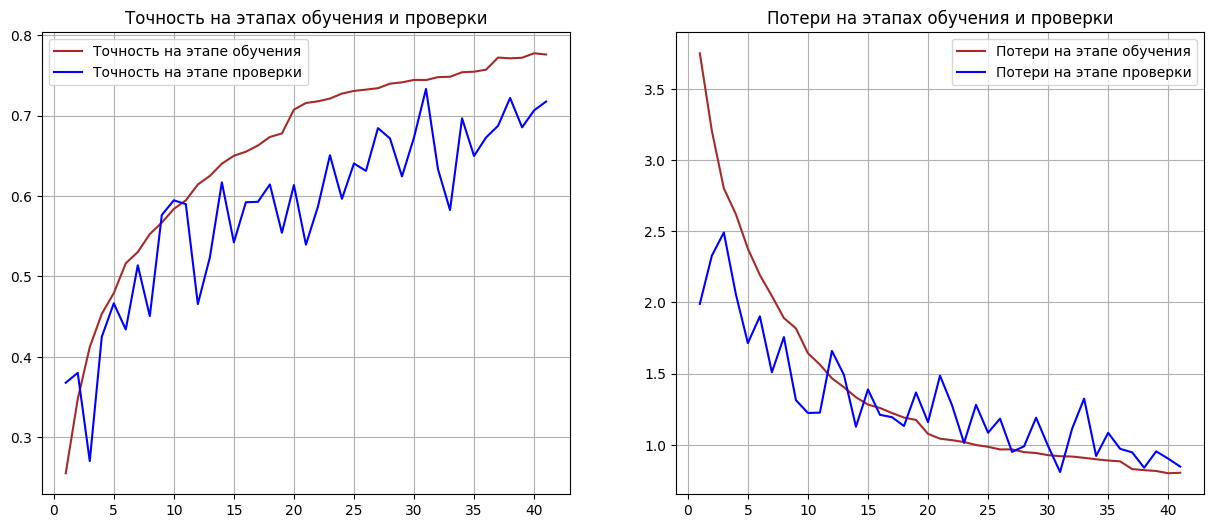

In [ ]:
plothistory(history_0)

In [ ]:
print(model_0.evaluate(test_ds))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7200 - loss: 0.7917
[0.804526150226593, 0.72265625]


In [ ]:
model_1 = models.Sequential()
model_1.add(layers.Input(shape=IMG_SIZE + (3,)))
model_1.add(layers.Rescaling(1./255))

model_1.add(data_augmentation)

model_1.add(layers.Conv2D(filters=8, kernel_size=3, padding='same', activation="relu"))# ))#
model_1.add(layers.MaxPooling2D(pool_size=2))
model_1.add(layers.BatchNormalization())
#model_1.add(layers.Activation('relu'))

model_1.add(layers.Conv2D(filters=16, kernel_size=3, padding='same', activation="relu"))# ))#
model_1.add(layers.MaxPooling2D(pool_size=2))
model_1.add(layers.BatchNormalization())
#model_1.add(layers.Activation('relu'))

model_1.add(layers.Conv2D(filters=32, kernel_size=3, padding='same', activation="relu"))# ))#
model_1.add(layers.MaxPooling2D(pool_size=2))
model_1.add(layers.BatchNormalization())
#model_1.add(layers.Activation('relu'))

model_1.add(layers.Conv2D(filters=64, kernel_size=3, padding='same', activation="relu"))# ))#
model_1.add(layers.MaxPooling2D(pool_size=2))
model_1.add(layers.BatchNormalization())
#model_1.add(layers.Activation('relu'))

model_1.add(layers.Conv2D(filters=128, kernel_size=3, padding='same', activation="relu"))# ))#
model_1.add(layers.MaxPooling2D(pool_size=2))
model_1.add(layers.BatchNormalization())
#model_1.add(layers.Activation('relu'))

model_1.add(layers.Conv2D(filters=256, kernel_size=3, padding='same', activation="relu"))# ))#
model_1.add(layers.MaxPooling2D(pool_size=2))
model_1.add(layers.BatchNormalization())
#model_1.add(layers.Activation('relu'))

model_1.add(layers.Flatten())
#model_1.add(layers.Dense(units=96, activation='relu'))

model_1.add(layers.Dropout(0.5))
model_1.add(layers.Dense(len(class_names), activation='softmax'))


In [ ]:
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             

 Total params: 436,538 (1.67 MB)

 Trainable params: 435,530 (1.66 MB)

 Non-trainable params: 1,008 (3.94 KB)

In [ ]:
model_1.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

callbacks_1 = [
  keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss'
  ),
  keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
  ),
  keras.callbacks.ModelCheckpoint(filepath="kr1_1.keras", save_best_only=True, monitor="val_loss")
]

history_1 = model_1.fit(
  train_ds,
  epochs=50,
  validation_data=val_ds,
  class_weight=class_weights,
  callbacks=callbacks_1,
  verbose=1
)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.2266 - loss: 3.7250 - val_accuracy: 0.2472 - val_loss: 2.6158 - learning_rate: 0.0010
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.3516 - loss: 2.7243 - val_accuracy: 0.3640 - val_loss: 2.1321 - learning_rate: 0.0010
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.4255 - loss: 2.3660 - val_accuracy: 0.3849 - val_loss: 1.9693 - learning_rate: 0.0010
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 66ms/step - accuracy: 0.4555 - loss: 2.2221 - val_accuracy: 0.3325 - val_loss: 2.4991 - learning_rate: 0.0010
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.4977 - loss: 1.9719 - val_accuracy: 0.4961 - val_loss: 1.5875 - learning_rate: 0.0010
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.5198 - loss: 1.8429 - val_accuracy: 0.4096 - val_loss: 1.8951 - learning_rate: 0.0010
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 49s 73ms/step - accuracy: 0.5430 - l

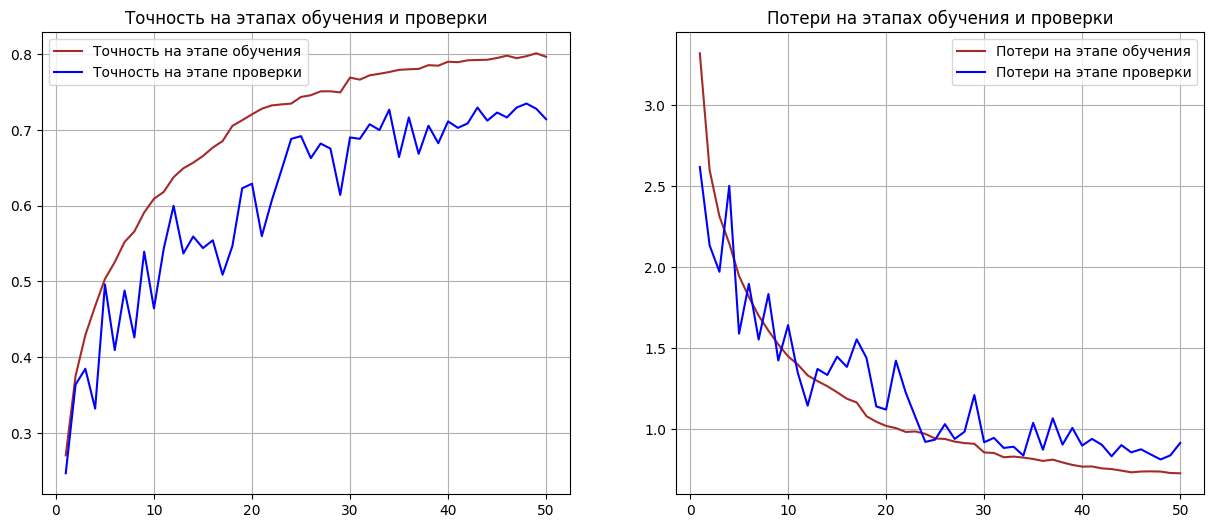

In [ ]:
plothistory(history_1)

In [ ]:
print(model_1.evaluate(test_ds))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7628 - loss: 0.7130
[0.802240788936615, 0.7412109375]


# Проверка на картинке

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
from keras.applications.vgg16 import preprocess_input
img = img_to_array(load_img('butterfly1.jpg', target_size=IMG_SIZE))
img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))
img = preprocess_input(img)

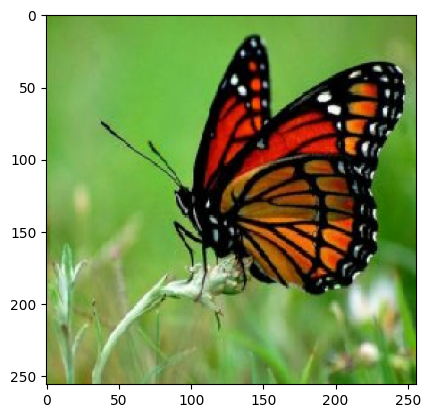

In [ ]:
plt.imshow(load_img('butterfly1.jpg', target_size=IMG_SIZE))

In [ ]:
model_0.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[8.2420804e-15, 2.7043964e-11, 2.5625636e-25, 9.9999988e-01,
        2.5234551e-14, 1.1726671e-11, 2.5333088e-13, 5.7458848e-18,
        1.6546276e-19, 1.3639604e-07]], dtype=float32)

In [ ]:
class_names[np.argmax(model_0.predict(img))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


'farfalla'

In [ ]:
model_1.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
class_names[np.argmax(model_1.predict(img))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


'farfalla'

# Предобученная модель

In [ ]:
pretrained = keras.applications.vgg16.VGG16(weights="imagenet", include_top=False, input_shape=IMG_SIZE+(3,))

In [ ]:
pretrained.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = pretrained.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)
train_features, train_labels = get_features_and_labels(train_ds)
val_features, val_labels = get_features_and_labels(val_ds)
test_features, test_labels = get_features_and_labels(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
train_features.shape

(20944, 8, 8, 512)

In [ ]:
vgg16_model = models.Sequential()
vgg16_model.add(keras.Input(shape=(8, 8, 512)))
vgg16_model.add(layers.Flatten())
vgg16_model.add(layers.Dense(256))
vgg16_model.add(layers.Dropout(0.5))
vgg16_model.add(layers.Dense(len(class_names), activation='softmax'))

In [ ]:
vgg16_model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

vgg16_callbacks = [
  keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
  ),
  keras.callbacks.ModelCheckpoint(filepath="vgg16.keras", save_best_only=True, monitor="val_loss")
]

vgg16_history = vgg16_model.fit(
  train_features, train_labels,
  epochs=20,
  validation_data=(val_features, val_labels),
  #class_weight=class_weights,
  callbacks=vgg16_callbacks,
  verbose=1
)

Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8418 - loss: 38.0795 - val_accuracy: 0.9423 - val_loss: 17.7382 - learning_rate: 0.0010
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9622 - loss: 8.9657 - val_accuracy: 0.9392 - val_loss: 20.4620 - learning_rate: 0.0010
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9726 - loss: 6.5346 - val_accuracy: 0.9380 - val_loss: 22.6224 - learning_rate: 0.0010
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9763 - loss: 4.9258 - val_accuracy: 0.9466 - val_loss: 22.6423 - learning_rate: 0.0010
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9811 - loss: 4.8227 - val_accuracy: 0.9440 - val_loss: 26.5560 - learning_rate: 0.0010
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9808 - loss: 5.9221 - val_accuracy: 0.9475 - val_loss: 29.3316 - learning_rate: 0.0010
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9887 - loss: 

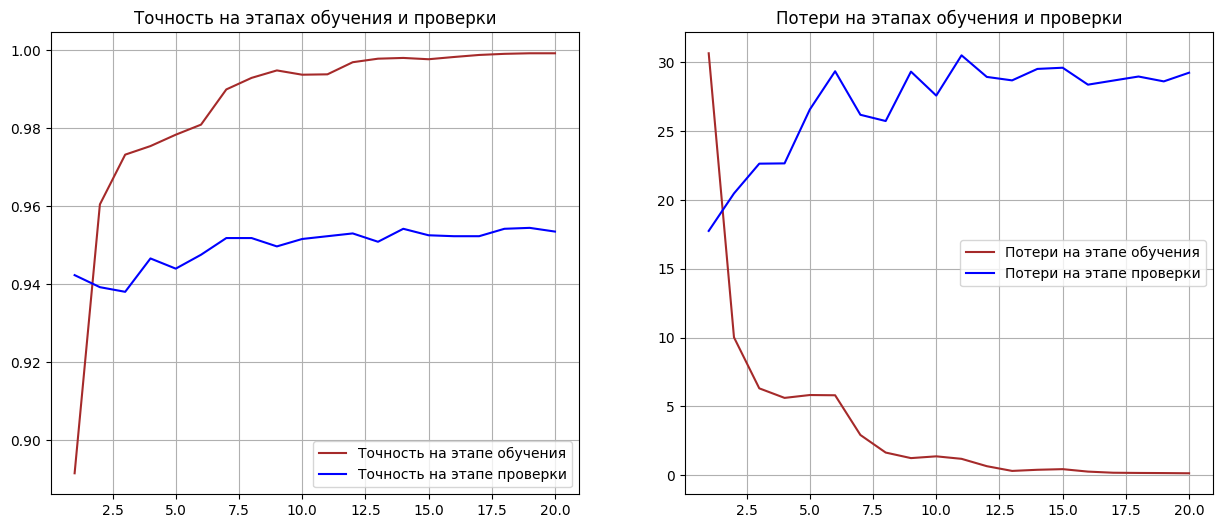

In [ ]:
plothistory(vgg16_history)

In [ ]:
vgg16_model.evaluate(test_features, test_labels)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9524 - loss: 23.7216


[18.098346710205078, 0.9619140625]

In [ ]:
img = load_img('butterfly1.jpg', target_size=IMG_SIZE)
img = img_to_array(img)
img = np.expand_dims(img, axis=0)
preprocessed_img = keras.applications.vgg16.preprocess_input(img)
features = pretrained.predict(preprocessed_img)
prediction = vgg16_model.predict(features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


In [ ]:
prediction

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
class_names[np.argmax(prediction)]

'farfalla'

# Выводы


В собственных моделях из-за дисбаланса классов пришлось рассчитать веса.

Результаты проверок собственных моделей на тестовой выборке:

model_0 - accuracy: 0.7200 - loss: 0.7917

model_1 - accuracy: 0.7628 - loss: 0.7130

Загруженную из интернета картинку обе модели определили верно - farfalla (бабочка)

Предобученная модель показала наилучшую точность:
vgg16_model - accuracy: accuracy: 0.9524 - loss: 23.7216

